<a href="https://colab.research.google.com/github/tacyataide/Revisao/blob/tacyataide-patch-1/Limiariza%C3%A7%C3%A3o_de_imagens_em_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Limiarização Global

A **limiarização global** é uma técnica de processamento de imagens utilizada para separar regiões de uma imagem com base na intensidade dos pixels.

Nesse método, é definido um único valor de **limiar (threshold)** que será aplicado a todos os pixels da imagem. Cada pixel é comparado com esse valor e seu resultado depende do tipo de limiarização escolhido.

Neste exemplo, utilizaremos a função `cv2.threshold()` do OpenCV para aplicar diferentes tipos de limiarização:

- `THRESH_BINARY`: pixels acima do limiar recebem o valor máximo e os demais recebem 0.
- `THRESH_BINARY_INV`: funciona de forma inversa ao método binário.
- `THRESH_TRUNC`: valores acima do limiar são limitados ao próprio valor do limiar.
- `THRESH_TOZERO`: valores abaixo do limiar são transformados em 0.
- `THRESH_TOZERO_INV`: valores acima do limiar são transformados em 0.

A imagem será carregada em **escala de cinza**, pois a comparação é realizada utilizando a intensidade de cada pixel.

Saving threshold.gif to threshold.gif


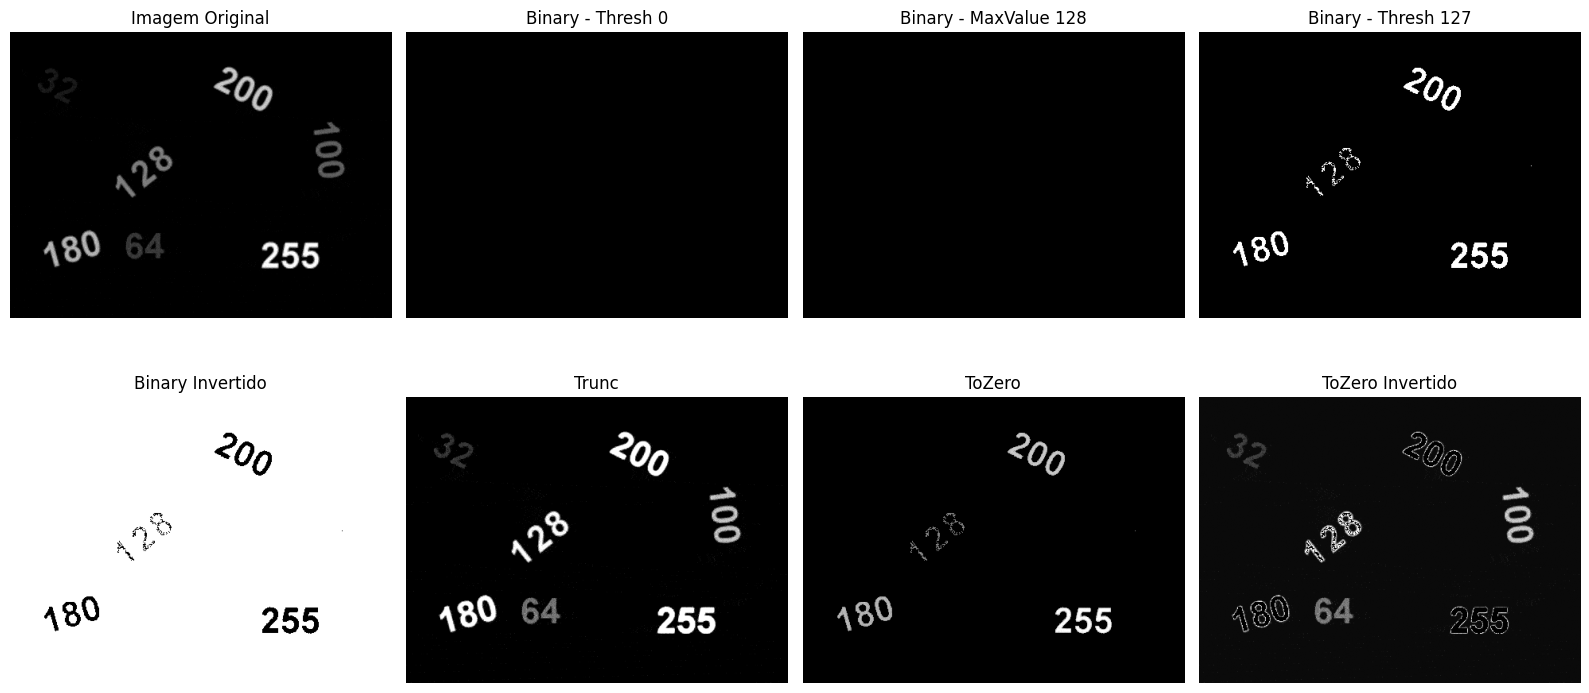

In [1]:
# Importando as bibliotecas
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload da imagem
uploaded = files.upload()

# Obtendo o nome da imagem enviada
nome_imagem = next(iter(uploaded))

# Lendo a imagem em escala de cinza
src = cv2.imread(nome_imagem, cv2.IMREAD_GRAYSCALE)

# Aplicando diferentes tipos de limiarização

# Limiarização binária com limiar 0 e valor máximo 255
_, binary_0 = cv2.threshold(
    src, 0, 255, cv2.THRESH_BINARY
)

# Limiarização binária com valor máximo 128
_, binary_128 = cv2.threshold(
    src, 0, 128, cv2.THRESH_BINARY
)

# Limiarização binária com limiar 127
_, binary = cv2.threshold(
    src, 127, 255, cv2.THRESH_BINARY
)

# Limiarização binária invertida
_, binary_inv = cv2.threshold(
    src, 127, 255, cv2.THRESH_BINARY_INV
)

# Limiarização truncada
_, trunc = cv2.threshold(
    src, 127, 255, cv2.THRESH_TRUNC
)

# Limiarização TOZERO
_, tozero = cv2.threshold(
    src, 127, 255, cv2.THRESH_TOZERO
)

# Limiarização TOZERO invertida
_, tozero_inv = cv2.threshold(
    src, 127, 255, cv2.THRESH_TOZERO_INV
)

# Organizando as imagens para exibição
imagens = [
    src,
    binary_0,
    binary_128,
    binary,
    binary_inv,
    trunc,
    tozero,
    tozero_inv
]

titulos = [
    "Imagem Original",
    "Binary - Thresh 0",
    "Binary - MaxValue 128",
    "Binary - Thresh 127",
    "Binary Invertido",
    "Trunc",
    "ToZero",
    "ToZero Invertido"
]

# Exibindo os resultados
plt.figure(figsize=(16, 8))

for i in range(len(imagens)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imagens[i], cmap="gray")
    plt.title(titulos[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 1. Limiarização Binária (THRESH_BINARY)

A **limiarização binária** é o tipo mais simples de limiarização. Ela transforma a imagem em apenas dois níveis de intensidade.

Cada pixel da imagem é comparado com um valor de limiar (`thresh`):

- Se o valor do pixel for **maior que o limiar**, ele recebe o valor máximo (`maxValue`).
- Se o valor do pixel for **menor ou igual ao limiar**, ele recebe o valor **0**.

A regra pode ser representada da seguinte forma:

    if src(x,y) > thresh:
        dst(x,y) = maxValue
    else:
        dst(x,y) = 0

No exemplo abaixo, utilizamos `thresh = 127` e `maxValue = 255`. Assim, os pixels acima de 127 se tornam brancos (255) e os demais se tornam pretos (0).

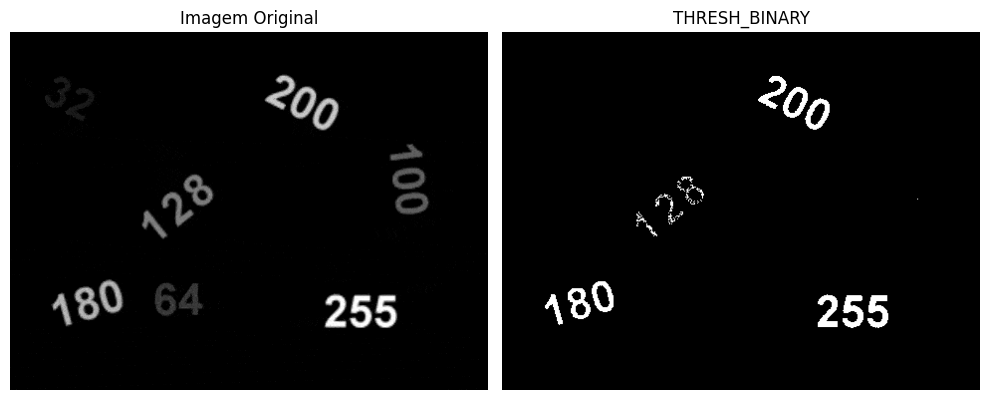

In [3]:
# Definindo o valor do limiar
thresh = 127

# Definindo o valor máximo
maxValue = 255

# Aplicando a limiarização binária
th, dst = cv2.threshold(
    src,
    thresh,
    maxValue,
    cv2.THRESH_BINARY
)

# Exibindo a imagem original e o resultado
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(src, cmap="gray")
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dst, cmap="gray")
plt.title("THRESH_BINARY")
plt.axis("off")

plt.tight_layout()
plt.show()

## Comparação da Limiarização Binária

Agora vamos observar como a alteração dos parâmetros `thresh` e `maxValue` influencia o resultado da limiarização binária.

Serão testadas três configurações:

- **`thresh = 0` e `maxValue = 255`**: pixels maiores que 0 recebem o valor 255.
- **`thresh = 127` e `maxValue = 255`**: pixels maiores que 127 recebem o valor 255 e os demais recebem 0.
- **`thresh = 0` e `maxValue = 128`**: pixels maiores que 0 recebem o valor 128.

Com essa comparação, podemos visualizar de forma simples a função de cada parâmetro na transformação da imagem.

Saving threshold.gif to threshold (2).gif


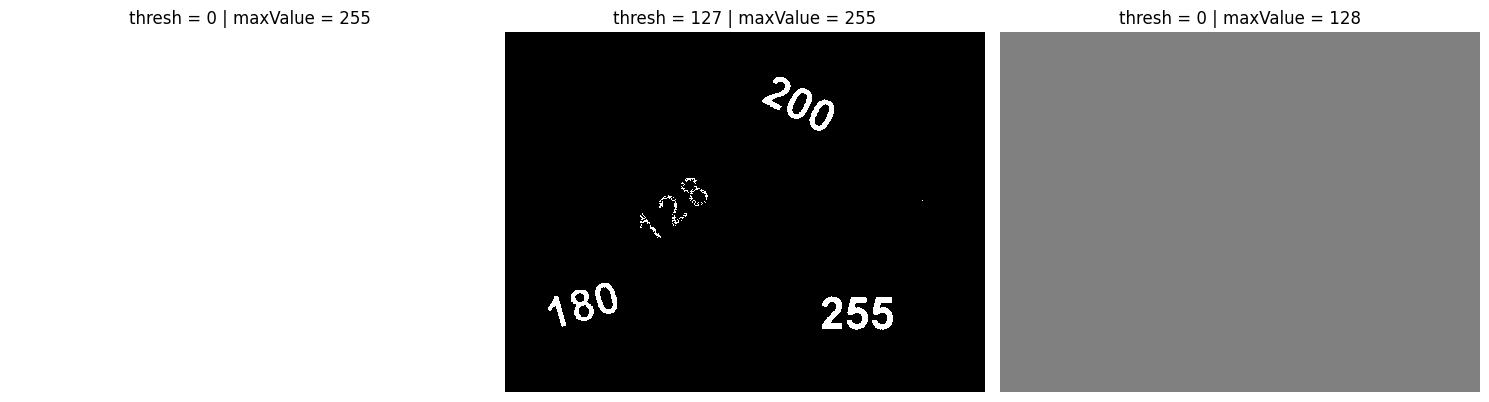

In [6]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload da imagem threshold.png
uploaded = files.upload()

# Nome do arquivo enviado
nome_imagem = next(iter(uploaded))

# Leitura da imagem em escala de cinza
src = cv2.imread(nome_imagem, cv2.IMREAD_GRAYSCALE)

# 1 - thresh = 0 e maxValue = 255
_, img1 = cv2.threshold(
    src,
    0,
    255,
    cv2.THRESH_BINARY
)

# 2 - thresh = 127 e maxValue = 255
_, img2 = cv2.threshold(
    src,
    127,
    255,
    cv2.THRESH_BINARY
)

# 3 - thresh = 0 e maxValue = 128
_, img3 = cv2.threshold(
    src,
    0,
    128,
    cv2.THRESH_BINARY
)

# Exibindo os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img1, cmap="gray", vmin=0, vmax=255)
plt.title("thresh = 0 | maxValue = 255")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap="gray", vmin=0, vmax=255)
plt.title("thresh = 127 | maxValue = 255")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img3, cmap="gray", vmin=0, vmax=255)
plt.title("thresh = 0 | maxValue = 128")
plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Limiarização Binária Inversa (THRESH_BINARY_INV)

A **Limiarização Binária Inversa** funciona de maneira oposta à limiarização binária comum.

Cada pixel da imagem é comparado com o valor definido em `thresh`:

- Se o pixel for **maior que o limiar**, ele recebe o valor **0 (preto)**.
- Se o pixel for **menor ou igual ao limiar**, ele recebe o valor definido em `maxValue` (branco, quando usamos 255).

A regra utilizada é:

    if src(x,y) > thresh:
        dst(x,y) = 0
    else:
        dst(x,y) = maxValue

Neste exemplo, utilizaremos `thresh = 127` e `maxValue = 255`.

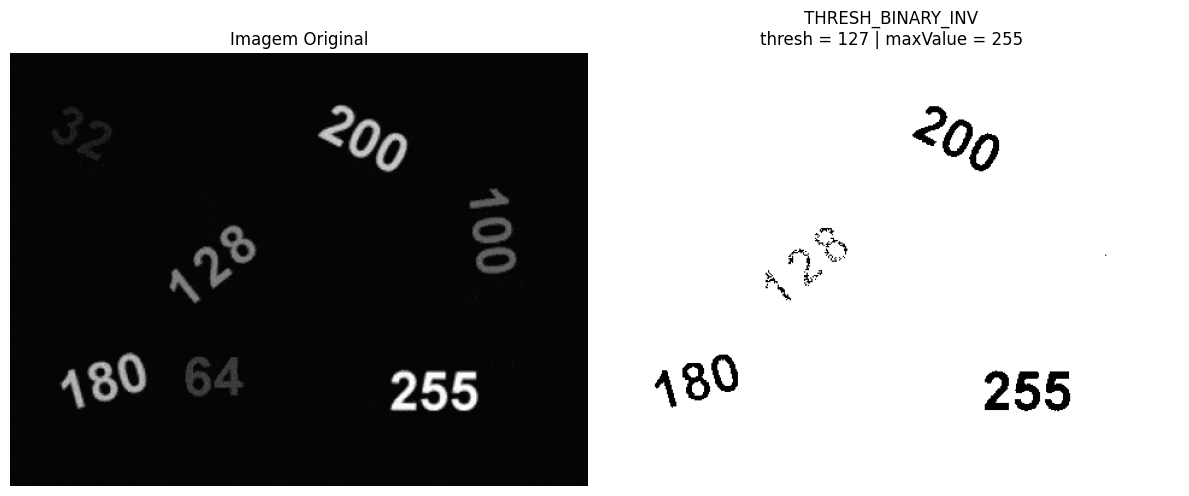

In [7]:
# Definindo os valores
thresh = 127
maxValue = 255

# Aplicando a limiarização binária inversa
_, binary_inv = cv2.threshold(
    src,
    thresh,
    maxValue,
    cv2.THRESH_BINARY_INV
)

# Exibindo a imagem original e o resultado
plt.figure(figsize=(12, 5))

# Imagem original
plt.subplot(1, 2, 1)
plt.imshow(src, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem Original")
plt.axis("off")

# Limiarização binária inversa
plt.subplot(1, 2, 2)
plt.imshow(binary_inv, cmap="gray", vmin=0, vmax=255)
plt.title("THRESH_BINARY_INV\nthresh = 127 | maxValue = 255")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Limiarização de Truncamento (THRESH_TRUNC)

A **Limiarização de Truncamento** limita a intensidade máxima dos pixels da imagem.

Cada pixel é comparado com o valor definido em `thresh`:

- Se o pixel for **maior que o limiar**, ele passa a receber o próprio valor de `thresh`.
- Se o pixel for **menor ou igual ao limiar**, seu valor original é mantido.
- O parâmetro `maxValue` não é utilizado nesse tipo de limiarização.

A regra utilizada é:

    if src(x,y) > thresh:
        dst(x,y) = thresh
    else:
        dst(x,y) = src(x,y)

Neste exemplo, utilizaremos `thresh = 127`.

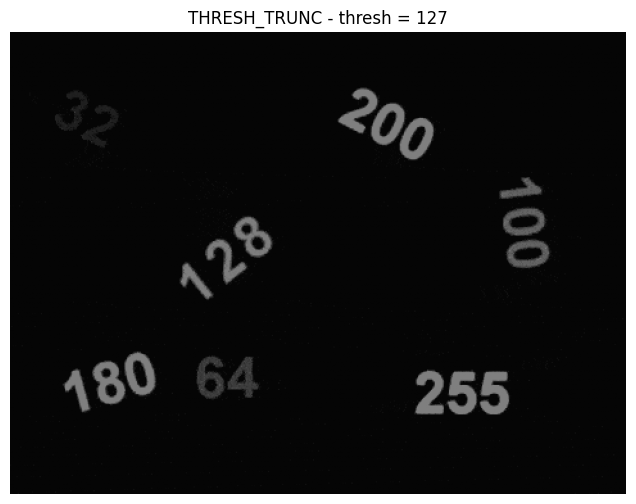

In [11]:
# Valor do limiar
thresh = 127

# O maxValue é ignorado no THRESH_TRUNC
maxValue = 255

# Aplicando a limiarização por truncamento
_, dst_trunc = cv2.threshold(
    src,
    thresh,
    maxValue,
    cv2.THRESH_TRUNC
)

# Exibindo somente o resultado
plt.figure(figsize=(8, 6))

plt.imshow(dst_trunc, cmap="gray", vmin=0, vmax=255)
plt.title("THRESH_TRUNC - thresh = 127")
plt.axis("off")

plt.show()

## 4. Limiar para Zero (THRESH_TOZERO)

O **Limiar para Zero** mantém os pixels que possuem intensidade maior que o valor do limiar e transforma os demais pixels em zero.

Neste exemplo, utilizamos `thresh = 127`.

A regra funciona da seguinte forma:

- Se o valor do pixel for **maior que 127**, seu valor original é mantido.
- Se o valor do pixel for **menor ou igual a 127**, ele recebe o valor **0 (preto)**.
- O parâmetro `maxValue` é ignorado neste tipo de limiarização.

A regra pode ser representada por:

    if src(x,y) > thresh:
        dst(x,y) = src(x,y)
    else:
        dst(x,y) = 0

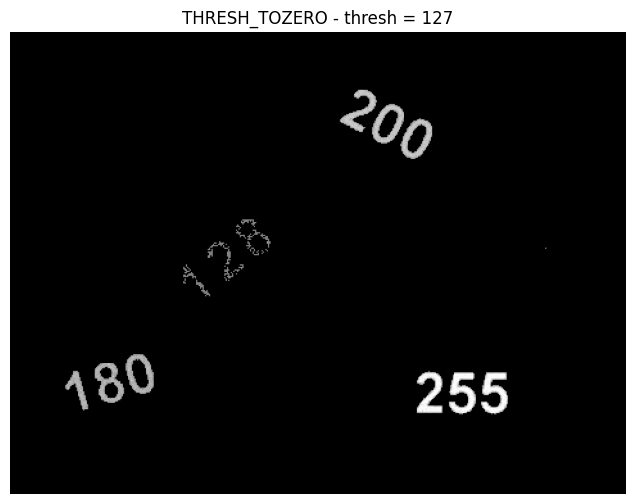

In [14]:
# Valor do limiar
thresh = 127

# O maxValue é ignorado no THRESH_TOZERO
maxValue = 255

# Aplicando o limiar para zero
_, dst_tozero = cv2.threshold(
    src,
    thresh,
    maxValue,
    cv2.THRESH_TOZERO
)

# Exibindo somente o resultado
plt.figure(figsize=(8, 6))

plt.imshow(dst_tozero, cmap="gray", vmin=0, vmax=255)
plt.title("THRESH_TOZERO - thresh = 127")
plt.axis("off")

plt.show()

## 5. Limiar Invertido para Zero (THRESH_TOZERO_INV)

O **Limiar Invertido para Zero** realiza o processo contrário ao `THRESH_TOZERO`.

Neste exemplo, utilizamos `thresh = 127`.

A regra funciona da seguinte forma:

- Se o valor do pixel for **maior que 127**, ele é transformado em **0 (preto)**.
- Se o valor do pixel for **menor ou igual a 127**, sua intensidade original é mantida.
- O parâmetro `maxValue` é ignorado neste tipo de limiarização.

A regra pode ser representada por:

    if src(x,y) > thresh:
        dst(x,y) = 0
    else:
        dst(x,y) = src(x,y)

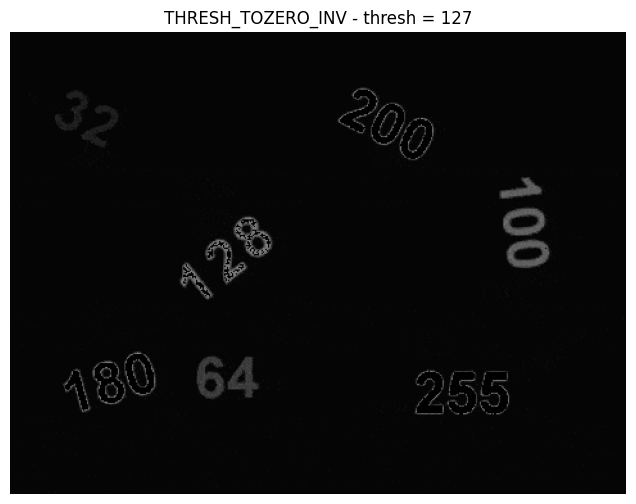

In [15]:
# Valor do limiar
thresh = 127

# O maxValue é ignorado no THRESH_TOZERO_INV
maxValue = 255

# Aplicando o limiar invertido para zero
_, dst_tozero_inv = cv2.threshold(
    src,
    thresh,
    maxValue,
    cv2.THRESH_TOZERO_INV
)

# Exibindo somente o resultado
plt.figure(figsize=(8, 6))

plt.imshow(dst_tozero_inv, cmap="gray", vmin=0, vmax=255)
plt.title("THRESH_TOZERO_INV - thresh = 127")
plt.axis("off")

plt.show()

### Resultado do Limiar Invertido para Zero

Com `thresh = 127`, os valores menores ou iguais a 127 mantêm suas intensidades originais:

- `5 → 5`
- `32 → 32`
- `64 → 64`
- `100 → 100`

Já os valores maiores que 127 são transformados em zero:

- `128 → 0`
- `180 → 0`
- `200 → 0`
- `255 → 0`

Como o valor 0 representa o preto, os números acima do limiar deixam de ser visíveis.

Entretanto, podem aparecer pequenos contornos nos números removidos. Isso ocorre porque os pixels das bordas podem possuir intensidades menores ou iguais a 127. Esses pixels não são transformados em zero e permanecem visíveis.

Assim, o `THRESH_TOZERO_INV` preserva as regiões de menor intensidade e elimina as regiões com intensidade acima do limiar.